In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
        print(dirname)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/varun000reddy
/kaggle/input/datasets/varun000reddy/training
/kaggle/input/datasets/varun000reddy/training/train
/kaggle/input/datasets/varun000reddy/training/train/annos
/kaggle/input/datasets/varun000reddy/training/train/image
/kaggle/input/datasets/varun000reddy/validation
/kaggle/input/datasets/varun000reddy/validation/validation
/kaggle/input/datasets/varun000reddy/validation/validation/annos
/kaggle/input/datasets/varun000reddy/validation/validation/image


In [6]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [7]:
IMAGE_PATH = "/kaggle/input/datasets/varun000reddy/training/train/image"
ANNO_PATH = "/kaggle/input/datasets/varun000reddy/training/train/annos"


In [8]:
sample = os.listdir(ANNO_PATH)[0]

with open(os.path.join(ANNO_PATH,sample)) as f:
    data = json.load(f)

print(data.keys())

print(data["item1"])

dict_keys(['item2', 'source', 'pair_id', 'item1'])
{'segmentation': [[381, 306, 334, 289, 297, 266, 261, 350, 225, 451, 216, 482, 268, 501, 273, 465, 312, 368, 279, 465, 263, 513, 315, 534, 332, 482, 362, 389, 381, 306], [334, 289, 297, 266, 261, 350, 225, 451, 216, 482, 268, 501, 273, 465, 312, 368, 334, 289], [381, 306, 334, 289, 312, 368, 279, 465, 263, 513, 315, 534, 332, 482, 362, 389, 381, 306]], 'scale': 2, 'viewpoint': 2, 'zoom_in': 1, 'landmarks': [297, 266, 1, 334, 289, 1, 381, 306, 1, 261, 350, 2, 225, 451, 2, 216, 482, 2, 268, 501, 2, 273, 465, 2, 312, 368, 2, 279, 465, 2, 263, 513, 2, 315, 534, 2, 332, 482, 2, 362, 389, 2], 'style': 2, 'bounding_box': [209, 263, 387, 539], 'category_id': 8, 'occlusion': 2, 'category_name': 'trousers'}


# Extracting top 5 categories

In [9]:
category_count = defaultdict(int)

for file in os.listdir(ANNO_PATH):

    if file.endswith(".json"):

        with open(os.path.join(ANNO_PATH,file)) as f:
            data = json.load(f)

        for key in data:
            if key.startswith("item"):
                cat = data[key]["category_id"]
                category_count[cat] += 1


sorted_counts = sorted(category_count.items(),
                       key=lambda x: x[1],
                       reverse=True)

print(sorted_counts[:10])

[(1, 71645), (8, 55387), (7, 36616), (2, 36064), (9, 30835), (12, 17949), (10, 17211), (5, 16095), (4, 13457), (11, 7907)]


In [10]:
top5 = [c[0] for c in sorted_counts[:5]]

print("Top 5 categories:", top5)

Top 5 categories: [1, 8, 7, 2, 9]


In [11]:
class_map = {cat:i for i,cat in enumerate(top5)}

print(class_map)

{1: 0, 8: 1, 7: 2, 2: 3, 9: 4}


In [12]:
category_map = {
    1: "short sleeve top",
    2: "long sleeve top",
    3: "short sleeve outwear",
    4: "long sleeve outwear",
    5: "vest",
    6: "sling",
    7: "shorts",
    8: "trousers",
    9: "skirt",
    10: "short sleeve dress",
    11: "long sleeve dress",
    12: "vest dress",
    13: "sling dress"
}


In [13]:
import json

label_map = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}

with open("/kaggle/working/label_map.json", "w") as f:
    json.dump(label_map, f, indent=4)

print("Saved label_map.json")

Saved label_map.json


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

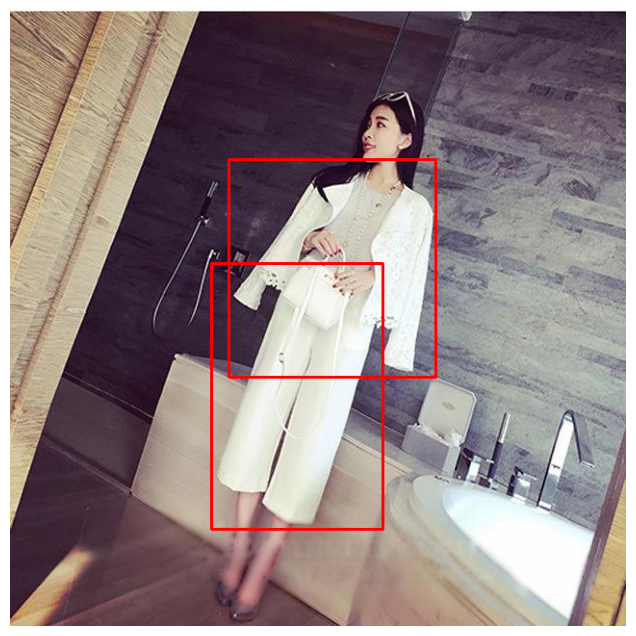

In [14]:
sample_file = os.listdir(ANNO_PATH)[0]

with open(os.path.join(ANNO_PATH, sample_file)) as f:
    data = json.load(f)

image_file = sample_file.replace(".json",".jpg")

img = cv2.imread(os.path.join(IMAGE_PATH,image_file))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for key in data:
    if key.startswith("item"):

        box = data[key]["bounding_box"]
        x1,y1,x2,y2 = box

        cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")

(np.float64(-0.5), np.float64(749.5), np.float64(519.5), np.float64(-0.5))

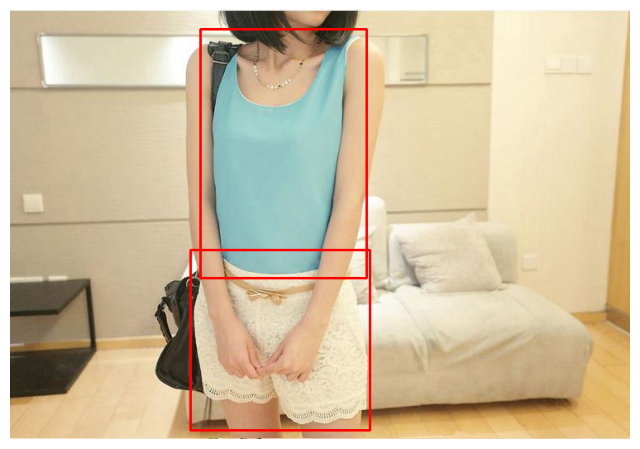

In [15]:
sample_file = os.listdir(ANNO_PATH)[3]

with open(os.path.join(ANNO_PATH, sample_file)) as f:
    data = json.load(f)

image_file = sample_file.replace(".json",".jpg")

img = cv2.imread(os.path.join(IMAGE_PATH,image_file))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for key in data:
    if key.startswith("item"):

        box = data[key]["bounding_box"]
        x1,y1,x2,y2 = box

        cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")

**Building Image Labels**

In [16]:
image_labels = {}

for file in os.listdir(ANNO_PATH):

    with open(os.path.join(ANNO_PATH,file)) as f:
        data = json.load(f)

    labels = np.zeros(len(top5))

    for key in data:
        if key.startswith("item"):
            cat = data[key]["category_id"]

            if cat in class_map:
                labels[class_map[cat]] = 1

    image_labels[file.replace(".json",".jpg")] = labels

In [17]:
print(len(image_labels))
for key in list(image_labels.keys())[:5]:
    print(key, image_labels[key])

191961
039350.jpg [0. 1. 0. 0. 0.]
098053.jpg [1. 0. 0. 0. 1.]
111638.jpg [0. 0. 0. 0. 0.]
189893.jpg [0. 0. 1. 0. 0.]
024710.jpg [0. 0. 0. 0. 0.]


**convert labels to dataframe**

In [18]:
import pandas as pd

rows = []

for img, label_vec in image_labels.items():

    row = {"image": img}

    for i in range(len(label_vec)):
        row[f"class_{i}"] = label_vec[i]

    rows.append(row)

df = pd.DataFrame(rows)

print(df.head())

        image  class_0  class_1  class_2  class_3  class_4
0  039350.jpg      0.0      1.0      0.0      0.0      0.0
1  098053.jpg      1.0      0.0      0.0      0.0      1.0
2  111638.jpg      0.0      0.0      0.0      0.0      0.0
3  189893.jpg      0.0      0.0      1.0      0.0      0.0
4  024710.jpg      0.0      0.0      0.0      0.0      0.0


**stratified sampling of dataset**

In [19]:
!pip install iterative-stratification
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

X = df["image"].values
y = df.iloc[:,1:].values

# **Perform 40% Stratified Sampling**

In [20]:
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.6,
    random_state=42
)

for train_idx, _ in msss.split(X, y):

    subset_images = X[train_idx]

**creating subset labels**

In [21]:
subset_labels = {}

for img in subset_images:
    subset_labels[img] = image_labels[img]

In [22]:
print("Original images:", len(image_labels))
print("Subset images:", len(subset_labels))

Original images: 191961
Subset images: 76784


in order for all my models to use same subset dataset: ****Saving subset****

In [23]:
import json

with open("/kaggle/working/train_subset.json","w") as f:
    json.dump(list(subset_images), f)

In [24]:
import os

print(os.listdir("/kaggle/working"))

['state.db', 'label_map.json', 'efficientnet_transfer_last.pth', 'efficientnet_finetune_last.pth', '.virtual_documents', 'efficientnet_last.pth', 'train_subset.json']


In [25]:
import json

with open("/kaggle/working/train_subset.json") as f:
    subset_images = json.load(f)

print(len(subset_images))
print(subset_images[:10])

76784
['098053.jpg', '189893.jpg', '059184.jpg', '183891.jpg', '115686.jpg', '139016.jpg', '161030.jpg', '038994.jpg', '158636.jpg', '165113.jpg']


**checking class distributions  - original**

In [26]:
print(df.iloc[:,1:].sum())

class_0    70586.0
class_1    54969.0
class_2    36332.0
class_3    35751.0
class_4    30625.0
dtype: float64


**checking class distribution - in subset **

In [27]:
subset_df = df[df["image"].isin(subset_images)]

print(subset_df.iloc[:,1:].sum())

class_0    28234.0
class_1    21987.0
class_2    14533.0
class_3    14300.0
class_4    12250.0
dtype: float64


**from above ratios of categories are same means, stratified sampling worked.**

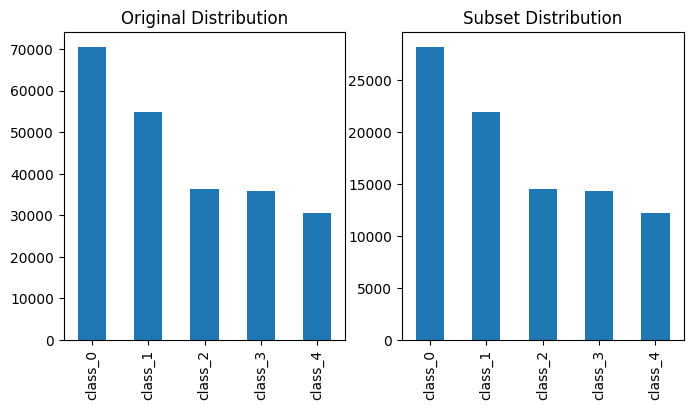

In [28]:
import matplotlib.pyplot as plt

original_counts = df.iloc[:,1:].sum()
subset_counts = subset_df.iloc[:,1:].sum()

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
original_counts.plot(kind="bar")
plt.title("Original Distribution")

plt.subplot(1,2,2)
subset_counts.plot(kind="bar")
plt.title("Subset Distribution")

plt.show()

**adding transformations for efficientnet as it expects 224x224 . (note this is done for efficientnet training it wont use bounding boxes but for detection it might affect as it needs bounding boxes and so original dimension)**

In [29]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# building dataset using subsample of 40% selected using stratified sampling

In [30]:
from torch.utils.data import Dataset
import torch

class ClothingDataset(Dataset):

    def __init__(self, image_path, image_labels, transform=None):
        self.image_path = image_path
        self.image_files = list(image_labels.keys())
        self.labels = image_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        img_name = self.image_files[idx]

        img = cv2.imread(os.path.join(self.image_path, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.labels[img_name]).float()

        return img, label

In [31]:
from torch.utils.data import DataLoader

dataset = ClothingDataset(IMAGE_PATH, subset_labels, transform=transform)   

#for full dataset, use below line 
#dataset = ClothingDataset(IMAGE_PATH, image_labels, transform=transform)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [32]:
images,labels = next(iter(loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 224, 224])
torch.Size([64, 5])


# **Class Weighting to deal with class imbalance**

In [33]:
import numpy as np

labels_matrix = np.array(list(subset_labels.values()))

class_counts = labels_matrix.sum(axis=0)

print("Class counts:", class_counts)

Class counts: [28234. 21987. 14533. 14300. 12250.]


# Training First Model (EfficientNet-B0) --training from scratch

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

cuda
True
Tesla T4


In [35]:
import torchvision.models as models
import torch.nn as nn

model = models.efficientnet_b0(weights=None)

model.classifier[1] = nn.Linear(1280,5)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)

model = model.to(device)


Using 2 GPUs


In [36]:
total_samples = labels_matrix.shape[0]

pos_weight = (total_samples - class_counts) / class_counts

print("Pos weights:", pos_weight)

pos_weight = torch.from_numpy(pos_weight).float().to(device)

Pos weights: [1.71955798 2.49224542 4.28342393 4.36951049 5.26808163]


In [37]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)

load checkpoint if it exists

In [38]:
checkpoint_path = "/kaggle/working/efficientnet_last.pth"
start_epoch = 0

train_loss_history = []
train_acc_history = []

reexecute below so to use checkpoint epoch saved 

In [39]:
import os

if os.path.exists(checkpoint_path):

    print("Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"]

    train_loss_history = checkpoint.get("loss_history", [])
    train_acc_history = checkpoint.get("acc_history", [])

    print("Resuming from epoch", start_epoch)

Loading checkpoint...
Resuming from epoch 35


In [40]:
def multilabel_accuracy(outputs, labels):

    probs = torch.sigmoid(outputs)

    preds = (probs > 0.5).float()

    correct = (preds == labels).float()

    acc = correct.mean()

    return acc

Training loop : real training  efficientnet b0

In [41]:
num_epochs = 35       #early stopping if increasing accuracy diff is very less
from tqdm import tqdm

for epoch in range(start_epoch, num_epochs):

    model.train()

    running_loss = 0
    running_acc = 0

    for images, labels in tqdm(loader):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        acc = multilabel_accuracy(outputs, labels)
        running_acc += acc.item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    train_loss_history.append(epoch_loss)
    train_acc_history.append(epoch_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")


   

    checkpoint = {
    "epoch": epoch + 1,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss_history": train_loss_history,
    "acc_history": train_acc_history
    }

    torch.save(checkpoint, checkpoint_path)

In [42]:
for i in range(len(train_loss_history)):
    print(f"Epoch {i+1} | Loss: {train_loss_history[i]:.4f} | Acc: {train_acc_history[i]:.4f}")

Epoch 1 | Loss: 0.7311 | Acc: 0.7620
Epoch 2 | Loss: 0.7045 | Acc: 0.7716
Epoch 3 | Loss: 0.6860 | Acc: 0.7787
Epoch 4 | Loss: 0.6646 | Acc: 0.7874
Epoch 5 | Loss: 0.6461 | Acc: 0.7956
Epoch 6 | Loss: 0.6293 | Acc: 0.8007
Epoch 7 | Loss: 0.6125 | Acc: 0.8062
Epoch 8 | Loss: 0.5982 | Acc: 0.8114
Epoch 9 | Loss: 0.5811 | Acc: 0.8184
Epoch 10 | Loss: 0.5680 | Acc: 0.8223
Epoch 11 | Loss: 0.5525 | Acc: 0.8270
Epoch 12 | Loss: 0.5410 | Acc: 0.8319
Epoch 13 | Loss: 0.5255 | Acc: 0.8371
Epoch 14 | Loss: 0.5141 | Acc: 0.8413
Epoch 15 | Loss: 0.5014 | Acc: 0.8459
Epoch 16 | Loss: 0.4888 | Acc: 0.8497
Epoch 17 | Loss: 0.4750 | Acc: 0.8537
Epoch 18 | Loss: 0.4653 | Acc: 0.8574
Epoch 19 | Loss: 0.4527 | Acc: 0.8626
Epoch 20 | Loss: 0.4448 | Acc: 0.8645
Epoch 21 | Loss: 0.4333 | Acc: 0.8675
Epoch 22 | Loss: 0.4224 | Acc: 0.8721
Epoch 23 | Loss: 0.4131 | Acc: 0.8746
Epoch 24 | Loss: 0.4036 | Acc: 0.8784
Epoch 25 | Loss: 0.3953 | Acc: 0.8807
Epoch 26 | Loss: 0.3871 | Acc: 0.8842
Epoch 27 | Loss: 0.37

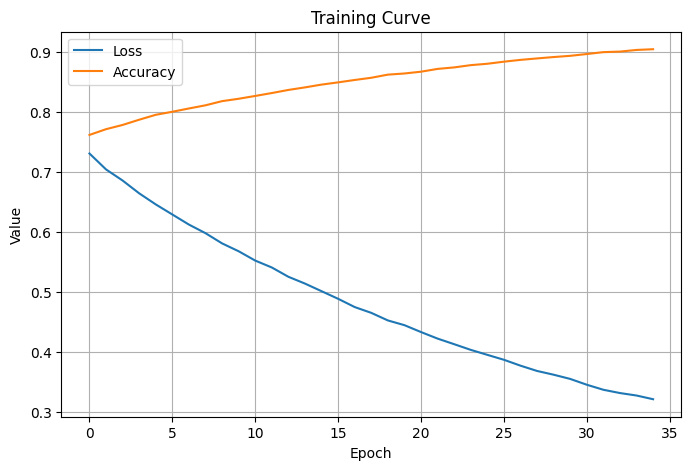

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_loss_history, label="Loss")
plt.plot(train_acc_history, label="Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Curve")
plt.legend()
plt.grid()
plt.show()

# NOW training efficientnet_B0 using transfer learning

In [44]:
import torchvision.models as models
import torch.nn as nn

model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1                 #loads imagenet pretrained weights for transfer learning
)


model.classifier[1] = nn.Linear(1280,5)

#freezes backbone layers , i.e, freezes convolutional layers and only trains the classifier
for param in model.features.parameters():
    param.requires_grad = False




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)

model = model.to(device)



criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)



import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)



Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s] 


Using 2 GPUs


In [45]:
def multilabel_accuracy(outputs, labels):

    probs = torch.sigmoid(outputs)

    preds = (probs > 0.5).float()

    correct = (preds == labels).float()

    acc = correct.mean()

    return acc


In [46]:
checkpoint_path = "/kaggle/working/efficientnet_transfer_last.pth"
start_epoch = 0

train_loss_history = []
train_acc_history = []

import os

if os.path.exists(checkpoint_path):

    print("Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"]

    train_loss_history = checkpoint.get("loss_history", [])
    train_acc_history = checkpoint.get("acc_history", [])

    print("Resuming from epoch", start_epoch)


Loading checkpoint...
Resuming from epoch 10


In [47]:
#reducing epochs because transfer learning converges Faster 
#it needs fewer epoch because it is already trained on weights of imagenet so it already understands edges,textures, shapes, general objects
#we are only adapting it to clothing category

num_epochs = 10     
from tqdm import tqdm

for epoch in range(start_epoch, num_epochs):

    model.train()

    running_loss = 0
    running_acc = 0

    for images, labels in tqdm(loader):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        acc = multilabel_accuracy(outputs, labels)
        running_acc += acc.item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    train_loss_history.append(epoch_loss)
    train_acc_history.append(epoch_acc)
    
    
    print(f"Transfer Learning Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")


    

    checkpoint = {
    "epoch": epoch + 1,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss_history": train_loss_history,
    "acc_history": train_acc_history
   }

    torch.save(checkpoint, checkpoint_path)

In [48]:
for i in range(len(train_loss_history)):
    print(f"Epoch {i+1} | Loss: {train_loss_history[i]:.4f} | Acc: {train_acc_history[i]:.4f}")

Epoch 1 | Loss: 0.9836 | Acc: 0.6176
Epoch 2 | Loss: 0.9210 | Acc: 0.6715
Epoch 3 | Loss: 0.9001 | Acc: 0.6825
Epoch 4 | Loss: 0.8882 | Acc: 0.6890
Epoch 5 | Loss: 0.8824 | Acc: 0.6908
Epoch 6 | Loss: 0.8782 | Acc: 0.6928
Epoch 7 | Loss: 0.8737 | Acc: 0.6956
Epoch 8 | Loss: 0.8710 | Acc: 0.6979
Epoch 9 | Loss: 0.8698 | Acc: 0.6980
Epoch 10 | Loss: 0.8684 | Acc: 0.6988


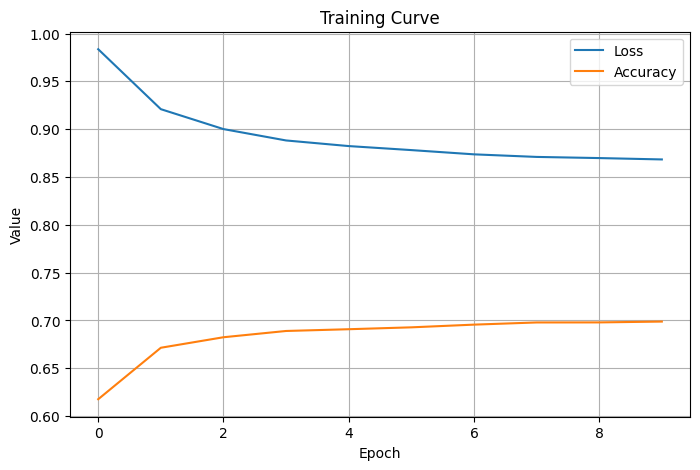

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_loss_history, label="Loss")
plt.plot(train_acc_history, label="Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Curve")
plt.legend()
plt.grid()
plt.show()

# NOW Training EfficientNet B0 using finetuning on transfer Learning

In [50]:
#unfreeze last efficientnet layers  i.e, unlocks last convolution blocks
for param in model.module.features[-2:].parameters():
    param.requires_grad = True

In [51]:
#new optimizer with smaller learning rate
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-5
)

In [52]:
checkpoint_path = "/kaggle/working/efficientnet_finetune_last.pth"
start_epoch = 0

train_loss_history = []
train_acc_history = []

import os

if os.path.exists(checkpoint_path):

    print("Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"]

    train_loss_history = checkpoint.get("loss_history", [])
    train_acc_history = checkpoint.get("acc_history", [])

    print("Resuming from epoch", start_epoch)


Loading checkpoint...
Resuming from epoch 20


In [53]:


num_epochs = 20     
from tqdm import tqdm

for epoch in range(start_epoch, num_epochs):

    model.train()

    running_loss = 0
    running_acc = 0

    for images, labels in tqdm(loader):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        acc = multilabel_accuracy(outputs, labels)
        running_acc += acc.item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    train_loss_history.append(epoch_loss)
    train_acc_history.append(epoch_acc)
    
    
    print(f"FineTuning Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")


    

    checkpoint = {
    "epoch": epoch + 1,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss_history": train_loss_history,
    "acc_history": train_acc_history
   }

    torch.save(checkpoint, checkpoint_path)

In [54]:
 for i in range(len(train_loss_history)):
     print(f"Epoch {i+1} | Loss: {train_loss_history[i]:.4f} | Acc: {train_acc_history[i]:.4f}")

Epoch 1 | Loss: 0.8493 | Acc: 0.7073
Epoch 2 | Loss: 0.8216 | Acc: 0.7210
Epoch 3 | Loss: 0.8032 | Acc: 0.7292
Epoch 4 | Loss: 0.7884 | Acc: 0.7371
Epoch 5 | Loss: 0.7757 | Acc: 0.7434
Epoch 6 | Loss: 0.7650 | Acc: 0.7492
Epoch 7 | Loss: 0.7530 | Acc: 0.7535
Epoch 8 | Loss: 0.7437 | Acc: 0.7576
Epoch 9 | Loss: 0.7362 | Acc: 0.7617
Epoch 10 | Loss: 0.7266 | Acc: 0.7657
Epoch 11 | Loss: 0.7213 | Acc: 0.7677
Epoch 12 | Loss: 0.7148 | Acc: 0.7711
Epoch 13 | Loss: 0.7078 | Acc: 0.7738
Epoch 14 | Loss: 0.6998 | Acc: 0.7769
Epoch 15 | Loss: 0.6956 | Acc: 0.7785
Epoch 16 | Loss: 0.6897 | Acc: 0.7808
Epoch 17 | Loss: 0.6849 | Acc: 0.7834
Epoch 18 | Loss: 0.6799 | Acc: 0.7855
Epoch 19 | Loss: 0.6750 | Acc: 0.7867
Epoch 20 | Loss: 0.6703 | Acc: 0.7894
Epoch 21 | Loss: 0.6663 | Acc: 0.7906
Epoch 22 | Loss: 0.6612 | Acc: 0.7920
Epoch 23 | Loss: 0.6577 | Acc: 0.7936
Epoch 24 | Loss: 0.6546 | Acc: 0.7948
Epoch 25 | Loss: 0.6493 | Acc: 0.7969
Epoch 26 | Loss: 0.6465 | Acc: 0.7982
Epoch 27 | Loss: 0.64

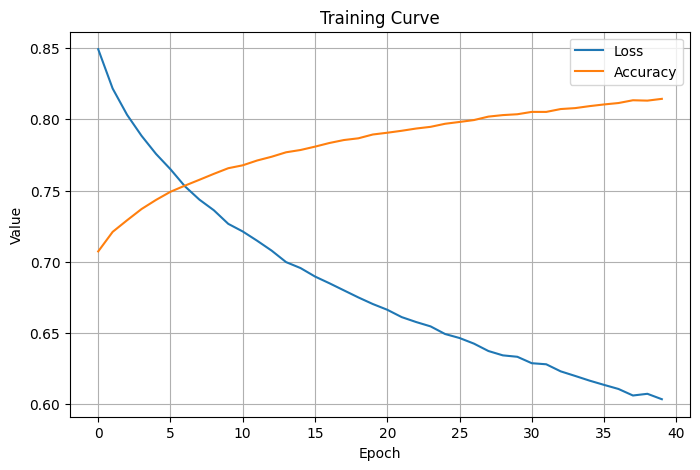

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_loss_history, label="Loss")
plt.plot(train_acc_history, label="Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Curve")
plt.legend()
plt.grid()
plt.show()

# Validation Pipeline 

In [78]:
IMAGE_PATH = "/kaggle/input/datasets/varun000reddy/validation/validation/image"
ANNO_PATH = "/kaggle/input/datasets/varun000reddy/validation/validation/annos"

creating validation labels

In [57]:
import os, json
import numpy as np

val_image_labels = {}

for file in os.listdir(ANNO_PATH):

    with open(os.path.join(ANNO_PATH, file)) as f:
        data = json.load(f)

    labels = np.zeros(len(top5))

    for key in data:
        if key.startswith("item"):
            cat = data[key]["category_id"]

            if cat in class_map:
                labels[class_map[cat]] = 1

    val_image_labels[file.replace(".json", ".jpg")] = labels

In [58]:
from torchvision import transforms

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [59]:
val_dataset = ClothingDataset(
    IMAGE_PATH,
    val_image_labels,
    transform=val_transform
)

from torch.utils.data import DataLoader

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Evaluating for Efficientnet: Training from scratch model

In [80]:
import torchvision.models as models
import torch.nn as nn

model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(1280,5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

model = model.to(device)


In [81]:
checkpoint_path = "/kaggle/working/efficientnet_last.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded model from epoch:", checkpoint["epoch"])

Loaded model from epoch: 35


In [82]:
model.eval()
from sklearn.metrics import f1_score, precision_score, recall_score

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

# merge batches
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

precision = precision_score(all_labels, all_preds, average="micro")
recall = recall_score(all_labels, all_preds, average="micro")
f1_micro = f1_score(all_labels, all_preds, average="micro")
f1_macro = f1_score(all_labels, all_preds, average="macro")

print("Validating Training from scratch model")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Micro:", f1_micro)
print("F1 Macro:", f1_macro)

Validating Training from scratch model
Precision: 0.632167525490626
Recall: 0.7505271652825867
F1 Micro: 0.6862815111047633
F1 Macro: 0.6640633037027126


In [83]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_per_class = precision_score(all_labels, all_preds, average=None)
recall_per_class = recall_score(all_labels, all_preds, average=None)
f1_per_class = f1_score(all_labels, all_preds, average=None)

for i in range(len(precision_per_class)):
    print(f"Class {i}:")
    print(f"  Precision: {precision_per_class[i]:.4f}")
    print(f"  Recall:    {recall_per_class[i]:.4f}")
    print(f"  F1 Score:  {f1_per_class[i]:.4f}")

Class 0:
  Precision: 0.7226
  Recall:    0.7310
  F1 Score:  0.7268
Class 1:
  Precision: 0.7360
  Recall:    0.8965
  F1 Score:  0.8083
Class 2:
  Precision: 0.5485
  Recall:    0.7087
  F1 Score:  0.6184
Class 3:
  Precision: 0.4995
  Recall:    0.6744
  F1 Score:  0.5739
Class 4:
  Precision: 0.5314
  Recall:    0.6704
  F1 Score:  0.5929


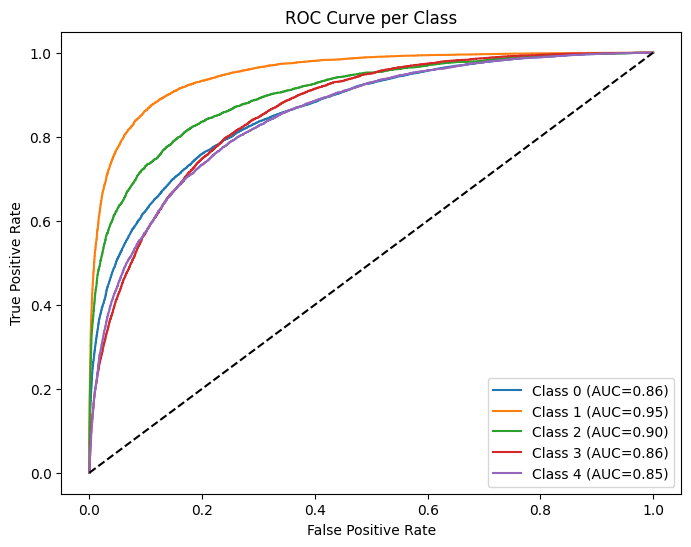

In [84]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

num_classes = all_labels.shape[1]

plt.figure(figsize=(8, 6))

for i in range(num_classes):
    # skip classes that have only one label value in validation
    if len(np.unique(all_labels[:, i])) < 2:
        print(f"Class {i}: ROC not defined in validation set")
        continue

    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class")
plt.legend()
plt.show()

# Evaluating for Efficientnet: Transfer Learning model

In [85]:
import torchvision.models as models
import torch.nn as nn

model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
model.classifier[1] = nn.Linear(1280,5)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

model = model.to(device)

In [86]:
checkpoint_path = "/kaggle/working/efficientnet_transfer_last.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded model from epoch:", checkpoint["epoch"])

Loaded model from epoch: 10


In [87]:
model.eval()
from sklearn.metrics import f1_score, precision_score, recall_score

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

# merge batches
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

precision = precision_score(all_labels, all_preds, average="micro")
recall = recall_score(all_labels, all_preds, average="micro")
f1_micro = f1_score(all_labels, all_preds, average="micro")
f1_macro = f1_score(all_labels, all_preds, average="macro")


print("Validating Transfer learning model")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Micro:", f1_micro)
print("F1 Macro:", f1_macro)

Validating Transfer learning model
Precision: 0.45113656849730405
Recall: 0.7166063572228152
F1 Micro: 0.5536960675852358
F1 Macro: 0.5332112036712884


In [88]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_per_class = precision_score(all_labels, all_preds, average=None)
recall_per_class = recall_score(all_labels, all_preds, average=None)
f1_per_class = f1_score(all_labels, all_preds, average=None)

for i in range(len(precision_per_class)):
    print(f"Class {i}:")
    print(f"  Precision: {precision_per_class[i]:.4f}")
    print(f"  Recall:    {recall_per_class[i]:.4f}")
    print(f"  F1 Score:  {f1_per_class[i]:.4f}")

Class 0:
  Precision: 0.5889
  Recall:    0.6999
  F1 Score:  0.6396
Class 1:
  Precision: 0.5896
  Recall:    0.7890
  F1 Score:  0.6749
Class 2:
  Precision: 0.2832
  Recall:    0.7205
  F1 Score:  0.4066
Class 3:
  Precision: 0.3659
  Recall:    0.6386
  F1 Score:  0.4652
Class 4:
  Precision: 0.3619
  Recall:    0.7110
  F1 Score:  0.4797


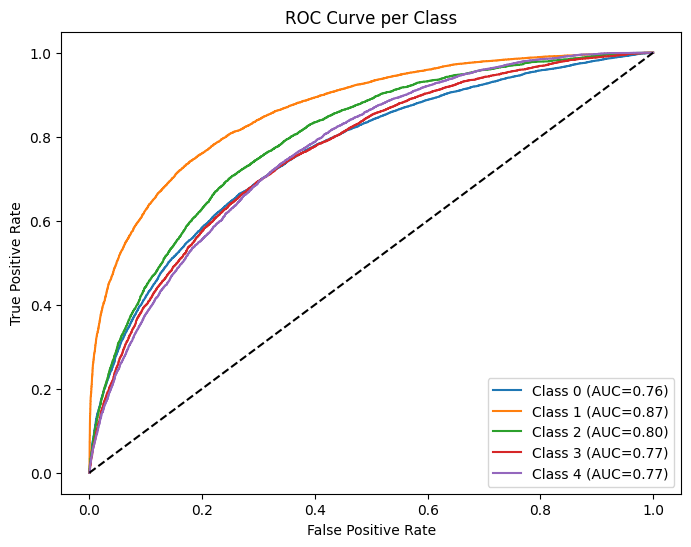

In [89]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

num_classes = all_labels.shape[1]

plt.figure(figsize=(8, 6))

for i in range(num_classes):
    # skip classes that have only one label value in validation
    if len(np.unique(all_labels[:, i])) < 2:
        print(f"Class {i}: ROC not defined in validation set")
        continue

    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class")
plt.legend()
plt.show()

# Evaluating for Efficientnet: Fine Tuning on Transfer learning model

using the same architecture as transfer learning model and finetuning

In [90]:
checkpoint_path = "/kaggle/working/efficientnet_finetune_last.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded model from epoch:", checkpoint["epoch"])

Loaded model from epoch: 20


In [91]:
model.eval()
from sklearn.metrics import f1_score, precision_score, recall_score

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

# merge batches
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

precision = precision_score(all_labels, all_preds, average="micro")
recall = recall_score(all_labels, all_preds, average="micro")
f1_micro = f1_score(all_labels, all_preds, average="micro")
f1_macro = f1_score(all_labels, all_preds, average="macro")



print("Validating Fine Tuning model")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Micro:", f1_micro)
print("F1 Macro:", f1_macro)

Validating Fine Tuning model
Precision: 0.5850541928123217
Recall: 0.8009788352901361
F1 Micro: 0.6761974879949013
F1 Macro: 0.6587409225774212


In [92]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_per_class = precision_score(all_labels, all_preds, average=None)
recall_per_class = recall_score(all_labels, all_preds, average=None)
f1_per_class = f1_score(all_labels, all_preds, average=None)

for i in range(len(precision_per_class)):
    print(f"Class {i}:")
    print(f"  Precision: {precision_per_class[i]:.4f}")
    print(f"  Recall:    {recall_per_class[i]:.4f}")
    print(f"  F1 Score:  {f1_per_class[i]:.4f}")

Class 0:
  Precision: 0.6930
  Recall:    0.7442
  F1 Score:  0.7177
Class 1:
  Precision: 0.7518
  Recall:    0.8954
  F1 Score:  0.8174
Class 2:
  Precision: 0.4749
  Recall:    0.7716
  F1 Score:  0.5879
Class 3:
  Precision: 0.4669
  Recall:    0.7606
  F1 Score:  0.5786
Class 4:
  Precision: 0.4612
  Recall:    0.8264
  F1 Score:  0.5920


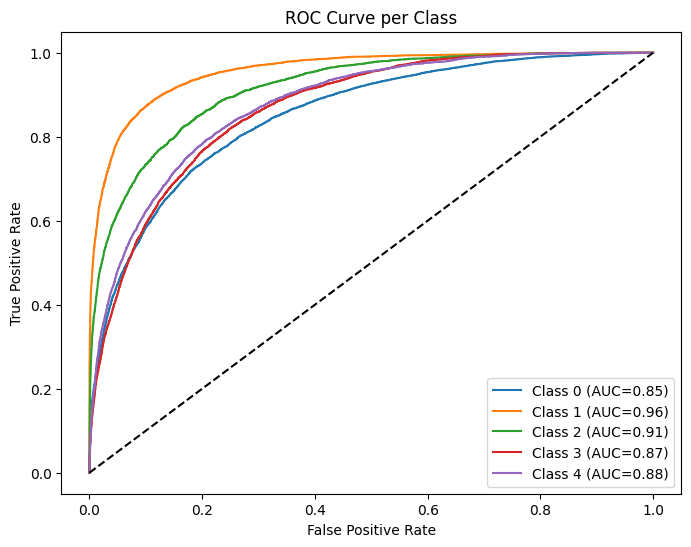

In [93]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

num_classes = all_labels.shape[1]

plt.figure(figsize=(8, 6))

for i in range(num_classes):
    # skip classes that have only one label value in validation
    if len(np.unique(all_labels[:, i])) < 2:
        print(f"Class {i}: ROC not defined in validation set")
        continue

    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class")
plt.legend()
plt.show()

# ------------------------------------------------------------------------

| # Model      | Training Type   | Train Acc    | Precision| Recall    | F1 Micro | F1 Macro |
| ------------ | -------------   | ---------    | -------  | --------- | ------   | -------- | 
| EfficientNet |Scratch(35 epoch)| 90.50        | 63.21    | 75.05     | 68.62    | 66.40     | 
| EfficientNet |Transfer(10 epoch)| 69.88        | 45.11    | 71.66     | 55.36    | 53.32     | 
| EfficientNet |Fine-tune(20 epoch)| 81.44        | 58.50    | 80.09     |  67.61   | 65.87     |


# Final comparison Table

# Validation Metrics comparison 

**Precision comparision**

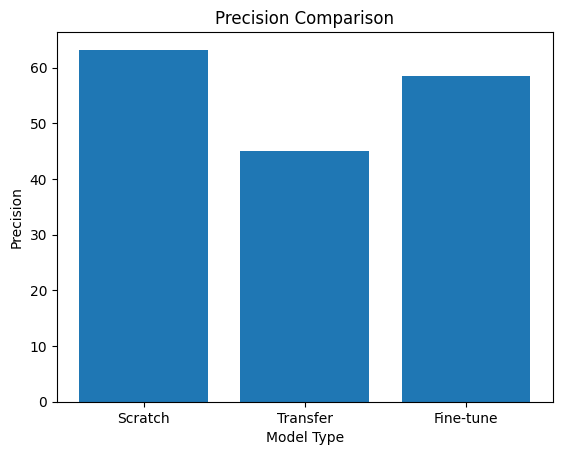

In [68]:
import matplotlib.pyplot as plt

models = ["Scratch", "Transfer", "Fine-tune"]
precision = [63.21, 45.11, 58.50]

plt.figure()
plt.bar(models, precision)
plt.title("Precision Comparison")
plt.xlabel("Model Type")
plt.ylabel("Precision")
plt.show()

-----------------------------------------------------------------------------------------------------

**Recall comparision**

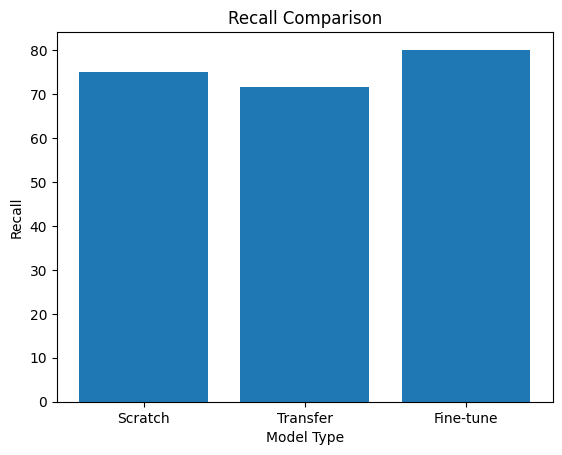

In [69]:
import matplotlib.pyplot as plt

models = ["Scratch", "Transfer", "Fine-tune"]
recall = [75.05, 71.66, 80.09]

plt.figure()
plt.bar(models, recall)
plt.title("Recall Comparison")
plt.xlabel("Model Type")
plt.ylabel("Recall")
plt.show()

--------------------------------------------------------------------------------------------------

**F1 micro**

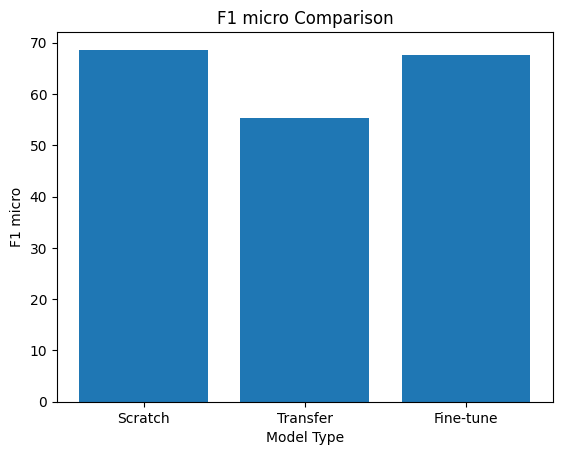

In [70]:
import matplotlib.pyplot as plt

models = ["Scratch", "Transfer", "Fine-tune"]
f1_micro = [68.62, 55.36, 67.61]

plt.figure()
plt.bar(models, f1_micro)
plt.title("F1 micro Comparison")
plt.xlabel("Model Type")
plt.ylabel("F1 micro")
plt.show()

----------------------------------------------------------------------------------------------

**F1 Macro**

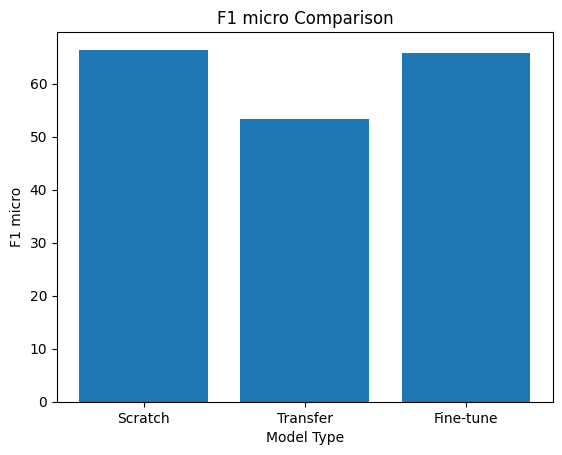

In [71]:
import matplotlib.pyplot as plt

models = ["Scratch", "Transfer", "Fine-tune"]
f1_micro = [66.40, 53.32, 65.87]

plt.figure()
plt.bar(models, f1_micro)
plt.title("F1 micro Comparison")
plt.xlabel("Model Type")
plt.ylabel("F1 micro")
plt.show()